<a href="https://colab.research.google.com/github/alexdemey/ProtectionGap/blob/main/protection_gap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install wbgapi

Sep 19

In [13]:
import pandas as pd

In [14]:
import numpy as np

In [15]:
import statsmodels.api as sm

In [16]:
import statsmodels.formula.api as smf

In [17]:
import matplotlib.pyplot as plt

In [18]:
!pip install wbgapi

In [19]:
import wbgapi as wb

In [20]:
df = pd.read_csv("/drop_blanks.csv", encoding="latin-1")


In [21]:
print(df.shape)
df.head()

(713, 33)


,DisNo.,iso3,Disaster Group,hazard,year,Country,insured_damage,total_damage,Insured Damage ('000 US$),Total Damage ('000 US$),...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2000-0012-MOZ,MOZ,Natural,Flood,2000,Mozambique,"2,804.00",783731,"1,500.00","419,200.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-0110-MOZ,MOZ,Natural,Storm,2019,Mozambique,"188,891.00",2518550,"150,000.00","2,000,000.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-0434-NPL,NPL,Natural,Flood,2009,Nepal,"7,503.00",90038,"5,000.00","60,000.00",...,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-0033-IND,IND,Natural,Earthquake,2001,India,"181,820.00",4769144,"100,000.00","2,623,000.00",...,54.40%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-0017-HTI,HTI,Natural,Earthquake,2010,Haiti,"295,285.00",11811414,"200,000.00","8,000,000.00",...,50.00%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df = df.rename(columns={
    "uncovered %": "uncovered",
    "Start Year": "year",
    "ISO": "iso3",
    "Disaster Type": "hazard",
    "Total Damage, Adjusted ('000 US$)": "total_damage",
    "Insured Damage, Adjusted ('000 US$)": "insured_damage",
})
print(list(df.columns))

['DisNo.', 'iso3', 'Disaster Group', 'hazard', 'year', 'Country', ' insured_damage ', 'total_damage', " Insured Damage ('000 US$) ", " Total Damage ('000 US$) ", 'CPI', ' gdp_pc ', 'credit_gdp', ' pop ', 'urban_share', 'rule_of_law', 'gov_eff', 'income_group', 'uncovered', 'log_gdp', '5 year blocks', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32']


In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("/content/drop_blanks.csv", encoding="latin-1")
print(df.shape)
df.head()

(713, 33)


,DisNo.,iso3,Disaster Group,hazard,year,Country,insured_damage,total_damage,Insured Damage ('000 US$),Total Damage ('000 US$),...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2000-0012-MOZ,MOZ,Natural,Flood,2000,Mozambique,"2,804.00",783731,"1,500.00","419,200.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-0110-MOZ,MOZ,Natural,Storm,2019,Mozambique,"188,891.00",2518550,"150,000.00","2,000,000.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-0434-NPL,NPL,Natural,Flood,2009,Nepal,"7,503.00",90038,"5,000.00","60,000.00",...,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-0033-IND,IND,Natural,Earthquake,2001,India,"181,820.00",4769144,"100,000.00","2,623,000.00",...,54.40%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-0017-HTI,HTI,Natural,Earthquake,2010,Haiti,"295,285.00",11811414,"200,000.00","8,000,000.00",...,50.00%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df.columns = df.columns.str.strip()
print(list(df.columns))

['DisNo.', 'iso3', 'Disaster Group', 'hazard', 'year', 'Country', 'insured_damage', 'total_damage', "Insured Damage ('000 US$)", "Total Damage ('000 US$)", 'CPI', 'gdp_pc', 'credit_gdp', 'pop', 'urban_share', 'rule_of_law', 'gov_eff', 'income_group', 'uncovered', 'log_gdp', '5 year blocks', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32']


In [26]:
df = df.rename(columns={
    "uncovered %": "uncovered",
    "Start Year": "year",
    "ISO": "iso3",
    "Disaster Type": "hazard",
    "Total Damage, Adjusted ('000 US$)": "total_damage",
    "Insured Damage, Adjusted ('000 US$)": "insured_damage",
    "gov_eff": "govt_eff",
})
print(list(df.columns))

['DisNo.', 'iso3', 'Disaster Group', 'hazard', 'year', 'Country', 'insured_damage', 'total_damage', "Insured Damage ('000 US$)", "Total Damage ('000 US$)", 'CPI', 'gdp_pc', 'credit_gdp', 'pop', 'urban_share', 'rule_of_law', 'govt_eff', 'income_group', 'uncovered', 'log_gdp', '5 year blocks', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32']


In [27]:
df["uncovered"] = (df["uncovered"].astype(str)
                     .str.replace("%", "", regex=False)
                     .str.strip())
df["uncovered"] = pd.to_numeric(df["uncovered"], errors="coerce")

if df["uncovered"].mean() > 1.5:
    df["uncovered"] = df["uncovered"] / 100

for col in ["log_gdp", "credit_gdp", "rule_of_law", "govt_eff", "total_damage"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        print("MISSING:", col)

print(df["uncovered"].describe())

count    683.000000
mean       0.544040
std        0.281356
min       -0.125000
25%        0.312500
50%        0.500000
75%        0.800000
max        1.000000
Name: uncovered, dtype: float64


In [28]:
bad = df[(df["uncovered"] < 0) | (df["uncovered"] > 1)]
print("impossible rows:", len(bad))
print(bad[["iso3", "year", "hazard", "total_damage", "insured_damage", "uncovered"]])

impossible rows: 3
    iso3  year    hazard  total_damage insured_damage  uncovered
66   JAM  2024     Storm         16318     16,729.00      -0.025
249  JPN  2007     Storm         93163    104,032.00      -0.117
594  USA  2015  Wildfire        543325    611,240.00      -0.125


In [29]:
df = df[(df["uncovered"] >= 0) & (df["uncovered"] <= 1)]
print("rows after impossible-value drop:", len(df))

rows after impossible-value drop: 680


In [30]:
print("rows:", len(df))
print("mean uncovered:", df["uncovered"].mean())
print("median uncovered:", df["uncovered"].median())
print("mean log_gdp:", df["log_gdp"].mean())
print(df.groupby("income_group")["uncovered"].mean())

rows: 680
mean uncovered: 0.5468323529411765
median uncovered: 0.5
mean log_gdp: 10.519969696969696
income_group
                       0.657667
High income            0.466769
Low income             0.960500
Lower middle income    0.896083
Upper middle income    0.789341
Name: uncovered, dtype: float64


In [31]:
df = df[df["total_damage"] > 0]
df["log_damage"] = np.log(df["total_damage"])
print("rows after zero-damage drop:", len(df))

rows after zero-damage drop: 680


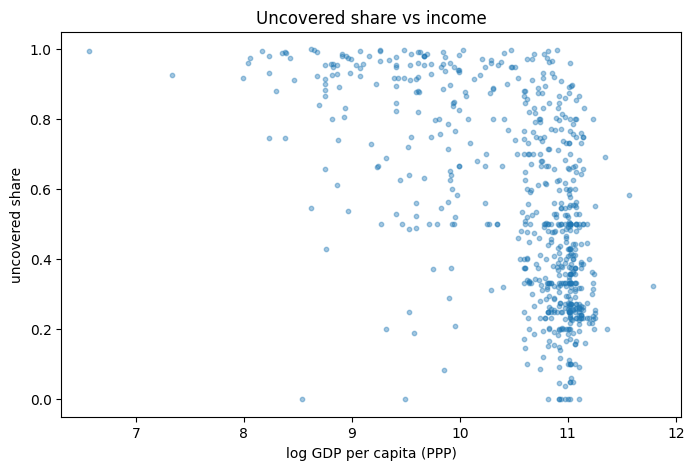

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df["log_gdp"], df["uncovered"], s=10, alpha=0.4)
plt.xlabel("log GDP per capita (PPP)")
plt.ylabel("uncovered share")
plt.title("Uncovered share vs income")
plt.show()

In [33]:
model_cols = ["uncovered", "log_gdp", "credit_gdp", "rule_of_law",
              "log_damage", "hazard", "year", "iso3"]

print(df[model_cols].isna().sum())

dfm = df.dropna(subset=model_cols).copy()
print("rows for modelling:", len(dfm))

uncovered       0
log_gdp        20
credit_gdp     66
rule_of_law    30
log_damage      0
hazard          0
year            0
iso3            0
dtype: int64
rows for modelling: 593


In [34]:
if "log_gdp" not in df.columns:
    df["gdp_pc"] = pd.to_numeric(df["gdp_pc"], errors="coerce")
    df["log_gdp"] = np.log(df["gdp_pc"].where(df["gdp_pc"] > 0))

model_cols = ["uncovered", "log_gdp", "credit_gdp", "rule_of_law",
              "log_damage", "hazard", "year", "iso3"]

print(df[model_cols].isna().sum())

dfm = df.dropna(subset=model_cols).copy()
print("rows for modelling:", len(dfm))

uncovered       0
log_gdp        20
credit_gdp     66
rule_of_law    30
log_damage      0
hazard          0
year            0
iso3            0
dtype: int64
rows for modelling: 593


In [35]:
print(dfm["hazard"].value_counts())
print(dfm["year"].value_counts().sort_index())

hazard
Storm                  331
Flood                  150
Earthquake              55
Wildfire                38
Drought                  8
Extreme temperature      7
Mass movement (wet)      4
Name: count, dtype: int64
year
2000    20
2002    23
2003    24
2004    28
2005    32
2006    15
2007    38
2008    26
2009    23
2010    28
2011    25
2012    37
2013    33
2014    28
2015    42
2016    39
2017    48
2018    13
2019    16
2020    15
2021    10
2022     8
2023    10
2024    12
Name: count, dtype: int64


In [36]:
keep = dfm["hazard"].value_counts()
keep = keep[keep >= 10].index
dfm = dfm[dfm["hazard"].isin(keep)].copy()
print("rows after dropping rare hazards:", len(dfm))
print(dfm["hazard"].value_counts())

rows after dropping rare hazards: 574
hazard
Storm         331
Flood         150
Earthquake     55
Wildfire       38
Name: count, dtype: int64


In [37]:
formula = ("uncovered ~ log_gdp + credit_gdp + rule_of_law"
           " + log_damage + C(hazard) + C(year)")

ols = smf.ols(formula, data=dfm).fit(
        cov_type="cluster", cov_kwds={"groups": dfm["iso3"]})
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              uncovered   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     71.99
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           8.60e-40
Time:                        16:31:02   Log-Likelihood:                 107.72
No. Observations:                 574   AIC:                            -153.4
Df Residuals:                     543   BIC:                            -18.52
Df Model:                          30                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.00

In [38]:
flog = smf.glm(formula, data=dfm,
        family=sm.families.Binomial()).fit(
        cov_type="cluster", cov_kwds={"groups": dfm["iso3"]})
print(flog.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              uncovered   No. Observations:                  574
Model:                            GLM   Df Residuals:                      543
Model Family:                Binomial   Df Model:                           30
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -254.20
Date:                Mon, 05 Oct 2026   Deviance:                       113.48
Time:                        16:31:02   Pearson chi2:                     110.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1493
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.59

In [39]:
cl = {"groups": dfm["iso3"]}

m1 = smf.ols("uncovered ~ log_gdp + C(hazard) + C(year)",
             data=dfm).fit(cov_type="cluster", cov_kwds=cl)
m2 = smf.ols("uncovered ~ log_gdp + credit_gdp + C(hazard) + C(year)",
             data=dfm).fit(cov_type="cluster", cov_kwds=cl)
m3 = smf.ols("uncovered ~ log_gdp + credit_gdp + rule_of_law"
             " + C(hazard) + C(year)",
             data=dfm).fit(cov_type="cluster", cov_kwds=cl)

for name, m in [("income only", m1), ("+ credit", m2), ("+ rule of law", m3)]:
    print(name, round(m.params["log_gdp"], 3), round(m.bse["log_gdp"], 3))

income only -0.184 0.024
+ credit -0.153 0.044
+ rule of law -0.06 0.028


In [40]:
def load(name):
    d = pd.read_csv(f"/content/{name}.csv", encoding="latin-1")
    d.columns = d.columns.str.strip()
    d = d.rename(columns={
        "uncovered %": "uncovered",
        "Start Year": "year",
        "ISO": "iso3",
        "Disaster Type": "hazard",
        "Total Damage, Adjusted ('000 US$)": "total_damage",
        "Insured Damage, Adjusted ('000 US$)": "insured_damage",
        "gov_eff": "govt_eff",
    })
    d["uncovered"] = (d["uncovered"].astype(str)
                        .str.replace("%", "", regex=False)
                        .str.strip())
    d["uncovered"] = pd.to_numeric(d["uncovered"], errors="coerce")
    if d["uncovered"].mean() > 1.5:
        d["uncovered"] = d["uncovered"] / 100

    for col in ["gdp_pc", "log_gdp", "credit_gdp", "rule_of_law",
                "govt_eff", "total_damage"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")

    if "log_gdp" not in d.columns:
        d["log_gdp"] = np.log(d["gdp_pc"].where(d["gdp_pc"] > 0))

    d = d[(d["uncovered"] >= 0) & (d["uncovered"] <= 1)]
    d = d[d["total_damage"] > 0]
    d["log_damage"] = np.log(d["total_damage"])

    missing = [c for c in model_cols if c not in d.columns]
    if missing:
        print(name, "MISSING COLUMNS:", missing)
        return None

    # NEW: show where the rows are going, per file
    print(name, "rows before dropna:", len(d))
    print(d[model_cols].isna().sum())

    d = d.dropna(subset=model_cols).copy()
    k = d["hazard"].value_counts()
    d = d[d["hazard"].isin(k[k >= 10].index)].copy()
    d["decade"] = (d["year"] // 10) * 10

    # NEW: refuse to model a dataset that's too small for the dummies
    n_params = 4 + d["hazard"].nunique() + d["year"].nunique()
    print(name, "rows after cleaning:", len(d), "| params needed:", n_params)
    if len(d) < n_params + 20:
        print(name, "TOO FEW ROWS for this formula — skipping")
        return None

    return d

for name in ["drop_blanks", "blanks_zero", "both_present"]:
    d = load(name)
    if d is None:
        continue
    # NEW: catch a failure on one dataset without killing the loop
    try:
        m = smf.ols(formula, data=d).fit(
                cov_type="cluster", cov_kwds={"groups": d["iso3"]})
        print("RESULT", name, len(d),
              round(m.params["log_gdp"], 3),
              round(m.bse["log_gdp"], 3))
    except Exception as e:
        print("RESULT", name, "FAILED:", type(e).__name__, e)
    print("-" * 50)

drop_blanks rows before dropna: 680
uncovered       0
log_gdp        20
credit_gdp     66
rule_of_law    30
log_damage      0
hazard          0
year            0
iso3            0
dtype: int64
drop_blanks rows after cleaning: 574 | params needed: 32
RESULT drop_blanks 574 -0.052 0.031
--------------------------------------------------
blanks_zero rows before dropna: 3263
uncovered        0
log_gdp        113
credit_gdp     386
rule_of_law    210
log_damage       0
hazard           0
year             0
iso3             0
dtype: int64
blanks_zero rows after cleaning: 2709 | params needed: 36
RESULT blanks_zero 2709 -0.018 0.012
--------------------------------------------------
both_present rows before dropna: 680
uncovered       0
log_gdp        20
credit_gdp     66
rule_of_law    30
log_damage      0
hazard          0
year            0
iso3            0
dtype: int64
both_present rows after cleaning: 574 | params needed: 32
RESULT both_present 574 -0.052 0.031
--------------------------

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = dfm[["log_gdp", "credit_gdp", "rule_of_law", "log_damage"]].dropna()
X = sm.add_constant(X)
for i, col in enumerate(X.columns):
    print(col, round(variance_inflation_factor(X.values, i), 1))

const 1.0
log_gdp 3.7
credit_gdp 2.0
rule_of_law 3.4
log_damage 1.1


In [42]:
dfg = dfm.dropna(subset=["govt_eff"]).copy()
formula_ge = formula.replace("rule_of_law", "govt_eff")
m_ge = smf.ols(formula_ge, data=dfg).fit(
         cov_type="cluster", cov_kwds={"groups": dfg["iso3"]})
print(m_ge.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.9712      0.345      2.818      0.005       0.296       1.647
C(hazard)[T.Flood]       -0.0674      0.047     -1.443      0.149      -0.159       0.024
C(hazard)[T.Storm]       -0.1795      0.062     -2.895      0.004      -0.301      -0.058
C(hazard)[T.Wildfire]    -0.1299      0.072     -1.813      0.070      -0.270       0.011
C(year)[T.2002]           0.0281      0.070      0.401      0.689      -0.110       0.166
C(year)[T.2003]          -0.0171      0.083     -0.205      0.838      -0.181       0.146
C(year)[T.2004]          -0.0213      0.071     -0.300      0.764      -0.160       0.118
C(year)[T.2005]          -0.0305      0.075     -0.409      0.683      -0.177       0.116
C(year)[T.2006]           0.0060      0.063      0.095      0.924      -0.118       0.130
C(year)[T.

In [43]:
splits = {
    "rich half": dfm[dfm["log_gdp"] >= dfm["log_gdp"].median()],
    "poor half": dfm[dfm["log_gdp"] <  dfm["log_gdp"].median()],
    "pre-2010":  dfm[dfm["year"] <= 2010],
    "post-2010": dfm[dfm["year"] >  2010],
}

for name, d in splits.items():
    m = smf.ols(formula, data=d).fit(
            cov_type="cluster", cov_kwds={"groups": d["iso3"]})
    print(name, len(d), round(m.params["log_gdp"], 3))

rich half 291 0.249
poor half 283 -0.046
pre-2010 249 -0.062
post-2010 325 -0.054


In [44]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. Load the dataset from the root directory
df = pd.read_csv("/drop_blanks.csv", encoding="latin-1")
df.columns = df.columns.str.strip()

# 2. Rename columns to match expected model variables
df = df.rename(columns={
    "uncovered %": "uncovered",
    "Start Year": "year",
    "ISO": "iso3",
    "Disaster Type": "hazard",
    "Total Damage, Adjusted ('000 US$)": "total_damage",
    "Insured Damage, Adjusted ('000 US$)": "insured_damage",
    "gov_eff": "govt_eff",
})

# 3. Clean and normalize 'uncovered' share
df["uncovered"] = (df["uncovered"].astype(str)
                     .str.replace("%", "", regex=False)
                     .str.strip())
df["uncovered"] = pd.to_numeric(df["uncovered"], errors="coerce")

if df["uncovered"].mean() > 1.5:
    df["uncovered"] = df["uncovered"] / 100

# 4. Convert numeric columns and filter values
for col in ["log_gdp", "credit_gdp", "rule_of_law", "govt_eff", "total_damage"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[(df["uncovered"] >= 0) & (df["uncovered"] <= 1)]
df = df[df["total_damage"] > 0]
df["log_damage"] = np.log(df["total_damage"])

# 5. Filter missing rows and drop rare hazard categories
model_cols = ["uncovered", "log_gdp", "credit_gdp", "rule_of_law", "log_damage", "hazard", "year", "iso3"]
dfm = df.dropna(subset=model_cols).copy()

keep = dfm["hazard"].value_counts()
keep = keep[keep >= 10].index
dfm = dfm[dfm["hazard"].isin(keep)].copy()

# 6. Define the regression formula
formula = ("uncovered ~ log_gdp + credit_gdp + rule_of_law"
           " + log_damage + C(hazard) + C(year)")

# 7. Perform split-sample analysis and output results
splits = {
    "rich half": dfm[dfm["log_gdp"] >= dfm["log_gdp"].median()],
    "poor half": dfm[dfm["log_gdp"] <  dfm["log_gdp"].median()],
    "pre-2010":  dfm[dfm["year"] <= 2010],
    "post-2010": dfm[dfm["year"] >  2010],
}

for name, d in splits.items():
    m = smf.ols(formula, data=d).fit(
            cov_type="cluster", cov_kwds={"groups": d["iso3"]})
    print(name, len(d), "countries:", d["iso3"].nunique(),
          "coef:", round(m.params["log_gdp"], 3),
          "SE:", round(m.bse["log_gdp"], 3),
          "p:", round(m.pvalues["log_gdp"], 3))

rich half 291 countries: 15 coef: 0.249 SE: 0.16 p: 0.121
poor half 283 countries: 56 coef: -0.046 SE: 0.036 p: 0.2
pre-2010 249 countries: 49 coef: -0.062 SE: 0.038 p: 0.104
post-2010 325 countries: 52 coef: -0.054 SE: 0.037 p: 0.143


In [45]:
import os

print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))

content_exists = os.path.exists('/content/drop_blanks.csv')
root_exists = os.path.exists('/drop_blanks.csv')
cwd_exists = os.path.exists('drop_blanks.csv')

print(f"File exists in '/content/drop_blanks.csv': {content_exists}")
print(f"File exists in '/drop_blanks.csv': {root_exists}")
print(f"File exists in current working directory: {cwd_exists}")

Current working directory: /content
Files in current directory: ['.config', 'blanks_zero.csv', 'both_present.csv', 'drop_blanks.csv', 'sample_data']
File exists in '/content/drop_blanks.csv': True
File exists in '/drop_blanks.csv': True
File exists in current working directory: True


In [46]:
print(dfm["iso3"].nunique(), dfm["year"].min(), dfm["year"].max())


67 2000 2024
